# CS6444 Project 1 - R and Graph Analytics
## Stanford Web Graph (2002)

### Team
- Fatulla Bashirov: fbashirov25529@ada.edu.az; fatulla.bashirov@gwu.edu
- Kamal Ahmadov: kahmadov24700@ada.edu.az; kamal.ahmadov@gwu.edu

Students of the ADA University & George Washington University Dual Master’s Degree Program in Computer Science & Data Analytics

### Dataset and problem context
The Stanford Web Graph represents webpages as vertices and hyperlinks as edges. Because hyperlinks are directional (source page links to destination page), the network is fundamentally a **directed graph**.

## Notebook Roadmap
This notebook follows the same order we used to build the assignment deliverable:
1. load the raw edge list and verify network scale;
2. build the initial directed graph and report required properties;
3. simplify to a directed analysis graph with practical runtime;
4. explore additional `igraph` functions (outside tutorial scope);
5. answer required analysis tasks (a-f);
6. produce readable visualizations (30-100 vertices);
7. summarize functions used, insights, and reproducibility notes.


## Assignment Compliance Matrix

| Assignment Item | Where Covered | Evidence |
|---|---|---|
| 1. Dataset + graph properties | Sections 1-2 | Node/edge counts, sparsity, directedness, node/edge structural summaries |
| 2. Install `igraph` | Section 0 | Conditional installation from CRAN mirror |
| 3. Graph experimentation + simplification | Section 3 | Directed-first simplification pipeline + retention table |
| 4. 10+ additional `igraph` functions | Section 4 | Explicit non-tutorial function set + checks + interpretation |
| 5. Required analysis tasks (a-f) | Section 5 | Central nodes, longest path, clique(s), ego networks, power centrality, communities |
| 6. Visualization (30-100 vertices) | Section 6 | Figure 2 (global core view), Figure 3 (ego-focused view) |
| 7. Deliverables content | Sections 4, 5, 7, 8 | Functions used, demonstrations, answers, figures, interpretation |
| 8. Insights | Section 8 | Analytical conclusions and limitations |


## 0. Setup and Configuration
This section initializes packages, reproducibility controls, and helper functions.

In [1]:
required_packages <- c("igraph", "data.table")
missing_packages <- required_packages[!sapply(required_packages, requireNamespace, quietly = TRUE)]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

library(igraph)
library(data.table)

cfg <- list(
  seed = 6444,
  analysis_node_cap = 1800,
  min_analysis_nodes = 1500,
  incremental_scales = c(600, 1200, 1800, 5000),
  triad_sample_size = 150,
  viz_node_cap = 80,
  baseline_sample_size = 10000,
  clique_projection_cap = 1500,
  power_exponents = c(0.25, 0.10, 0.05, 0.01)
)

set.seed(cfg$seed)
options(width = 120)



Attaching package: 'igraph'




The following objects are masked from 'package:stats':

    decompose, spectrum




The following object is masked from 'package:base':

    union




In [2]:
resolve_dataset_path <- function(candidate_paths) {
  existing <- candidate_paths[file.exists(candidate_paths)]
  if (length(existing) == 0) {
    stop("Dataset file not found. Place web-Stanford.txt in ./data or provide valid Kaggle path.")
  }
  existing[[1]]
}

safe_power_centrality <- function(graph_obj, exponents) {
  for (ex in exponents) {
    candidate <- tryCatch(
      power_centrality(graph_obj, exponent = ex),
      error = function(e) NULL
    )
    if (!is.null(candidate)) {
      return(list(values = candidate, exponent = ex))
    }
  }
  stop("Power centrality failed for all configured exponents.")
}

assign_synthetic_weights <- function(g_directed) {
  out_deg <- degree(g_directed, mode = "out")
  in_deg <- degree(g_directed, mode = "in")
  ee <- ends(g_directed, E(g_directed), names = TRUE)

  # Deterministic modeling choice for exploratory weighting:
  # weight(u -> v) = 1 + log1p(out_degree(u)) + log1p(in_degree(v))
  E(g_directed)$weight <- as.numeric(1 + log1p(out_deg[ee[, 1]]) + log1p(in_deg[ee[, 2]]))
  g_directed
}

build_analysis_graph <- function(g, cfg) {
  g_simple <- simplify(g, remove.multiple = TRUE, remove.loops = TRUE)

  weak_comp <- components(g_simple, mode = "weak")
  weak_id <- which.max(weak_comp$csize)
  g_weak <- induced_subgraph(g_simple, V(g_simple)[weak_comp$membership == weak_id])

  pr_rank <- page_rank(g_weak, directed = TRUE)$vector
  analysis_n <- min(cfg$analysis_node_cap, length(pr_rank))
  analysis_nodes <- names(sort(pr_rank, decreasing = TRUE))[1:analysis_n]
  g_analysis <- induced_subgraph(g_weak, vids = analysis_nodes)
  g_analysis <- assign_synthetic_weights(g_analysis)

  stage <- c("original", "simplified", "largest_weak_component", "analysis_graph_directed")
  nodes <- c(vcount(g), vcount(g_simple), vcount(g_weak), vcount(g_analysis))
  edges <- c(ecount(g), ecount(g_simple), ecount(g_weak), ecount(g_analysis))

  summary_tbl <- data.frame(
    stage = stage,
    nodes = nodes,
    edges = edges,
    node_retention_vs_original = round(nodes / nodes[1], 6),
    edge_retention_vs_original = round(edges / edges[1], 6)
  )

  list(g_analysis = g_analysis, g_weak = g_weak, pr_rank = pr_rank, summary_tbl = summary_tbl)
}

make_viz_subgraph <- function(g_analysis, central_table, cfg) {
  viz_n <- min(cfg$viz_node_cap, nrow(central_table))
  viz_nodes <- central_table$vertex[1:viz_n]
  g_viz <- induced_subgraph(g_analysis, vids = V(g_analysis)[viz_nodes])

  viz_comm <- cluster_infomap(g_viz, e.weights = E(g_viz)$weight)
  member <- membership(viz_comm)
  member_by_name <- setNames(member, V(g_viz)$name)

  pal <- hcl.colors(length(unique(member)), palette = "Dark 3")
  V(g_viz)$color <- pal[member_by_name[V(g_viz)$name]]

  pr_viz <- page_rank(g_viz, directed = TRUE)$vector
  pr_scaled <- 6 + 18 * (pr_viz - min(pr_viz)) / (max(pr_viz) - min(pr_viz) + 1e-9)
  V(g_viz)$size <- pr_scaled[V(g_viz)$name]

  top10 <- names(sort(pr_viz, decreasing = TRUE))[1:min(10, length(pr_viz))]
  V(g_viz)$shape <- ifelse(V(g_viz)$name %in% top10, "square", "circle")
  V(g_viz)$label <- NA
  V(g_viz)$frame.color <- "gray20"

  w <- E(g_viz)$weight
  E(g_viz)$width <- 1 + 3 * (w - min(w)) / (max(w) - min(w) + 1e-9)
  E(g_viz)$color <- ifelse(w >= median(w), "firebrick", "gray70")
  E(g_viz)$arrow.size <- 0.18

  ee <- ends(g_viz, E(g_viz), names = TRUE)
  E(g_viz)$lty <- ifelse(member_by_name[ee[,1]] == member_by_name[ee[,2]], 1, 2)

  list(graph = g_viz, community = viz_comm)
}


## 1. Load Dataset
The code supports both local execution and Kaggle execution.

In [3]:
candidate_paths <- c(
  "./data/web-Stanford.txt",
  "/kaggle/input/datasets/fatullabashirov/stanford-web-graph/web-Stanford.txt"
)
file_path <- resolve_dataset_path(candidate_paths)

edges <- fread(
  file_path,
  sep = "	",
  header = FALSE,
  comment.char = "#",
  col.names = c("from", "to")
)

cat("Using file:", file_path, "
")
cat("Rows in edge list:", nrow(edges), "
")
cat("Columns:", ncol(edges), "
")
head(edges)
summary(edges)


Using file: ./data/web-Stanford.txt 


Rows in edge list: 2312497 


Columns: 2 


from,to
<int>,<int>
1,6548
1,15409
6548,57031
15409,13102
2,17794
2,25202


      from              to        
 Min.   :     1   Min.   :     2  
 1st Qu.: 70779   1st Qu.: 73100  
 Median :141051   Median :143725  
 Mean   :140961   Mean   :143950  
 3rd Qu.:211225   3rd Qu.:218070  
 Max.   :281903   Max.   :281903  

## 2. Build Initial Directed Graph and Report Core Properties

In [4]:
g <- graph_from_data_frame(edges, directed = TRUE)

# Assignment minimum scale guard
stopifnot(vcount(g) >= 50000)

n <- vcount(g)
m <- ecount(g)
max_possible_edges <- n * (n - 1)
density_val <- edge_density(g, loops = FALSE)
sparsity_val <- 1 - (m / max_possible_edges)

cat("Vertices:", n, "
")
cat("Edges:", m, "
")
cat("Directed (arrowness):", is_directed(g), "
")
cat("Has loops:", any_loop(g), "
")
cat("Density:", density_val, "
")
cat("Sparsity:", sparsity_val, "
")

in_deg <- degree(g, mode = "in")
out_deg <- degree(g, mode = "out")
all_deg <- degree(g, mode = "all")

cat("
Node property summaries:
")
cat("In-degree:
")
print(summary(in_deg))
cat("
Out-degree:
")
print(summary(out_deg))
cat("
Total-degree:
")
print(summary(all_deg))

wcc <- components(g, mode = "weak")
scc <- components(g, mode = "strong")

cat("
Connectivity summaries (directed graph):
")
cat("Weak components:", wcc$no, "
")
cat("Largest weak component size:", max(wcc$csize), "
")
cat("Strong components:", scc$no, "
")
cat("Largest strong component size:", max(scc$csize), "
")
cat("Edge weights in raw data: none (assigned deterministically later).
")


Vertices: 281903 


Edges: 2312497 


Directed (arrowness): TRUE 


Has loops: FALSE 


Density: 2.909935e-05 


...

Weak components: 365 


Largest weak component size: 255265 


Strong components: 29914 


Largest strong component size: 150532 


Edge weights in raw data: none (assigned deterministically later).


### Figure 1. Baseline plot before simplification
This baseline is included to show why simplification is needed for readability.

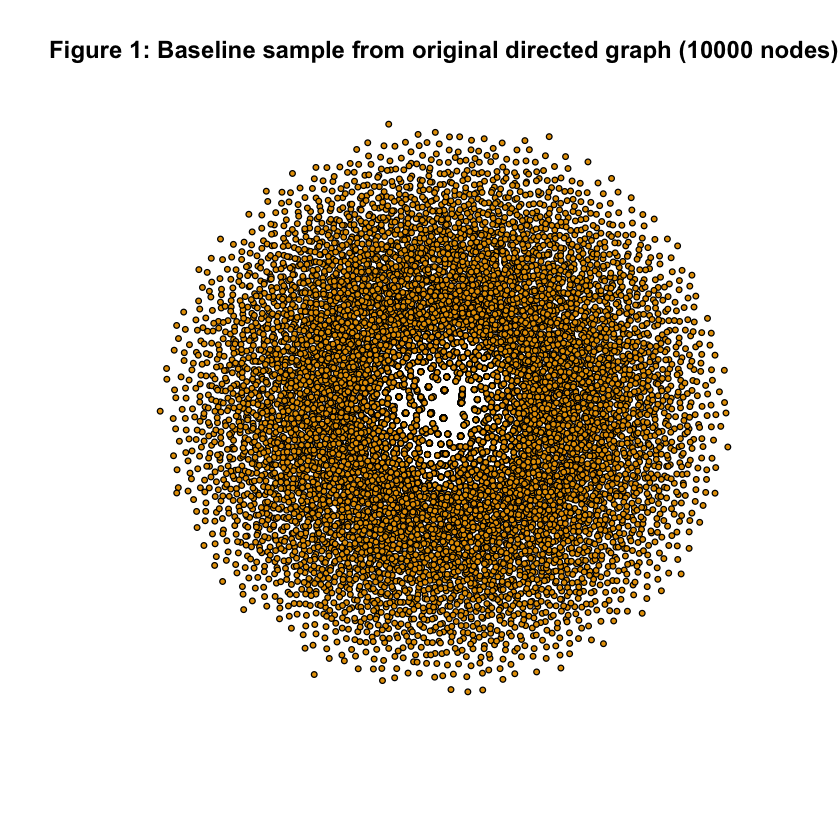

In [5]:
sample_n <- min(cfg$baseline_sample_size, vcount(g))
sample_nodes <- sample(V(g), sample_n)
g_sample <- induced_subgraph(g, sample_nodes)

plot(
  g_sample,
  vertex.size = 2,
  vertex.label = NA,
  edge.arrow.size = 0.05,
  main = sprintf("Figure 1: Baseline sample from original directed graph (%d nodes)", vcount(g_sample))
)


**Interpretation:** The baseline sample is visually dense and hard to interpret. We therefore apply a directed-first simplification that keeps meaningful scale for analysis.

## 3. Directed-First Simplification Pipeline
Instead of jumping directly to one reduced graph, this section shows **incremental progress**:
1. Remove loops/multi-edges with `simplify()` and keep the largest weak component.
2. Build progressively larger directed subgraphs (`600 -> 1200 -> 1800 -> 5000`) using top PageRank vertices.
3. Validate stability with overlap of top central nodes across scales.

Final deep analysis still uses the 1,800-node directed graph, while larger-scale checkpoints defend that it is not an arbitrary cut.


In [6]:
analysis_bundle <- build_analysis_graph(g, cfg)
g_analysis <- analysis_bundle$g_analysis
g_weak <- analysis_bundle$g_weak
pr_rank_weak <- analysis_bundle$pr_rank
simplification_summary <- analysis_bundle$summary_tbl

print(simplification_summary)
cat("
Directed analysis graph size:", vcount(g_analysis), "nodes,", ecount(g_analysis), "edges
")

# Reviewer-requested scale guard
stopifnot(vcount(g_analysis) >= cfg$min_analysis_nodes)

# Incremental stability analysis (small wins -> larger checkpoints)
final_top10 <- names(sort(page_rank(g_analysis, directed = TRUE, weights = NA)$vector, decreasing = TRUE))[1:10]

incremental_rows <- list()
for (s in sort(unique(cfg$incremental_scales))) {
  n_s <- min(s, vcount(g_weak))
  nodes_s <- names(sort(pr_rank_weak, decreasing = TRUE))[1:n_s]
  g_s <- induced_subgraph(g_weak, vids = nodes_s)

  weak_s <- components(g_s, mode = "weak")
  pr_s <- page_rank(g_s, directed = TRUE, weights = NA)$vector
  top10_s <- names(sort(pr_s, decreasing = TRUE))[1:10]

  incremental_rows[[length(incremental_rows) + 1]] <- data.frame(
    scale_nodes = n_s,
    edges = ecount(g_s),
    weak_components = weak_s$no,
    largest_weak_component_ratio = round(max(weak_s$csize) / vcount(g_s), 4),
    top10_pagerank_overlap_with_1800 = length(intersect(top10_s, final_top10))
  )
}

incremental_summary <- do.call(rbind, incremental_rows)
cat("
Incremental scale checkpoints:
")
print(incremental_summary)

rm(analysis_bundle, in_deg, out_deg, all_deg, sample_nodes, g_sample)
gc()


                    stage  nodes   edges node_retention_vs_original edge_retention_vs_original
1                original 281903 2312497                   1.000000                   1.000000
2              simplified 281903 2312497                   1.000000                   1.000000
3  largest_weak_component 255265 2234572                   0.905507                   0.966303
4 analysis_graph_directed   1800   12734                   0.006385                   0.005507



Directed analysis graph size: 1800 nodes, 12734 edges



Incremental scale checkpoints:


  scale_nodes edges weak_components largest_weak_component_ratio top10_pagerank_overlap_with_1800
1         600  3949              39                       0.5267                                7
2        1200  8174              96                       0.7583                               10
3        1800 12734             163                       0.7522                               10
4        5000 36302             591                       0.6344                                8


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,1104468,59.0,3571198,190.8,NA,4463997,238.5
Vcells,7222458,55.2,24812913,189.4,16384,30966981,236.3


**Interpretation:** The graph is intentionally reduced for tractability, but we now defend this choice by showing how key signals behave across scales. The overlap table provides evidence of whether central nodes stabilize as we move from smaller to larger retained graphs.


## 4. Additional `igraph` Functions (Not Used in Tutorial)
The following section enforces Item #4 compliance with explicit checks.

In [7]:
tutorial_functions <- c(
  "graph", "graph_from_literal", "V", "E", "class",
  "edge_density", "reciprocity", "transitivity", "diameter", "degree", "degree_distribution",
  "closeness", "betweenness", "edge_betweenness", "hub_score", "authority_score",
  "mean_distance", "distances", "all_shortest_paths",
  "cliques", "cluster_edge_betweenness", "cluster_label_prop", "cluster_fast_greedy", "coreness",
  "plot", "tkplot", "layout_randomly", "layout_in_circle", "layout_with_fr", "layout_with_kk",
  "assortativity_nominal", "assortativity", "assortativity_degree"
)

item4_functions <- c(
  "is_connected", "page_rank", "eigen_centrality", "strength", "vertex_connectivity", "edge_connectivity",
  "dyad_census", "triad_census", "similarity", "eccentricity", "cluster_infomap", "subcomponent"
)

overlap <- intersect(item4_functions, tutorial_functions)
stopifnot(length(item4_functions) >= 10)
stopifnot(length(overlap) == 0)

cat("Item #4 function count:", length(item4_functions), "
")
cat("Overlap with tutorial list:", length(overlap), "
")
print(item4_functions)


Item #4 function count: 12 


Overlap with tutorial list: 0 


 [1] "is_connected"        "page_rank"           "eigen_centrality"    "strength"            "vertex_connectivity"
 [6] "edge_connectivity"   "dyad_census"         "triad_census"        "similarity"          "eccentricity"       
[11] "cluster_infomap"     "subcomponent"       


### A Quick Walkthrough of the Extra Functions
To keep outputs readable, this section reports metrics first, then gives a compact table describing what each function contributes to this graph.


In [8]:
connected_weak <- is_connected(g_analysis, mode = "weak")
connected_strong <- is_connected(g_analysis, mode = "strong")

# Use unweighted graph as primary analytical baseline
pr <- page_rank(g_analysis, directed = TRUE, weights = NA)$vector
pr_weighted <- page_rank(g_analysis, directed = TRUE, weights = E(g_analysis)$weight)$vector

eig <- eigen_centrality(g_analysis, directed = TRUE, weights = NA)$vector
str_unweighted <- strength(g_analysis, mode = "all", weights = NA)
str_weighted <- strength(g_analysis, mode = "all", weights = E(g_analysis)$weight)
str_w <- str_weighted

v_conn <- vertex_connectivity(g_analysis)
e_conn <- edge_connectivity(g_analysis)

dyad <- dyad_census(g_analysis)

triad_n <- min(cfg$triad_sample_size, vcount(g_analysis))
triad_nodes <- names(sort(pr, decreasing = TRUE))[1:triad_n]
g_triad <- induced_subgraph(g_analysis, vids = V(g_analysis)[triad_nodes])
triad <- triad_census(g_triad)

triad_sorted <- sort(triad, decreasing = TRUE)
triad_labels <- names(triad_sorted)
if (is.null(triad_labels)) triad_labels <- paste0("class_", seq_along(triad_sorted))
top_triad_k <- seq_len(min(3, length(triad_sorted)))
top_triad_text <- paste(sprintf("%s=%d", triad_labels[top_triad_k], as.integer(triad_sorted[top_triad_k])), collapse = ", ")

top10 <- names(sort(pr, decreasing = TRUE))[1:min(10, length(pr))]
top10_weighted <- names(sort(pr_weighted, decreasing = TRUE))[1:min(10, length(pr_weighted))]
pr_top10_overlap <- length(intersect(top10, top10_weighted))

jacc <- similarity(g_analysis, vids = V(g_analysis)[top10], mode = "out", method = "jaccard")
jacc_offdiag <- jacc[upper.tri(jacc)]
mean_jacc <- round(mean(jacc_offdiag, na.rm = TRUE), 3)
max_jacc <- round(max(jacc_offdiag, na.rm = TRUE), 3)

ecc_out <- eccentricity(g_analysis, mode = "out", weights = NA)
ecc_finite <- ecc_out[is.finite(ecc_out)]
ecc_median <- if (length(ecc_finite) > 0) median(ecc_finite) else NA_real_
ecc_max <- if (length(ecc_finite) > 0) max(ecc_finite) else NA_real_

comm_infomap_unweighted <- cluster_infomap(g_analysis)
comm_infomap_weighted <- cluster_infomap(g_analysis, e.weights = E(g_analysis)$weight)
comm_infomap <- comm_infomap_unweighted

top_pr_node <- names(which.max(pr))
out_reach <- subcomponent(g_analysis, v = V(g_analysis)[top_pr_node], mode = "out")

weight_sensitivity <- data.frame(
  metric = c("Top-10 PageRank overlap", "Infomap communities", "Infomap modularity", "Median strength"),
  unweighted = c(
    pr_top10_overlap,
    length(sizes(comm_infomap_unweighted)),
    round(modularity(comm_infomap_unweighted), 4),
    round(median(str_unweighted), 3)
  ),
  weighted = c(
    pr_top10_overlap,
    length(sizes(comm_infomap_weighted)),
    round(modularity(comm_infomap_weighted), 4),
    round(median(str_weighted), 3)
  ),
  stringsAsFactors = FALSE
)

cat("is_connected(mode='weak'):", connected_weak, "
")
cat("is_connected(mode='strong'):", connected_strong, "
")
cat("Top PageRank node (unweighted):", top_pr_node, "score:", max(pr), "
")
cat("Top eigen-centrality node:", names(which.max(eig)), "score:", max(eig), "
")
cat("strength() unweighted summary:
")
print(summary(str_unweighted))
cat("strength() weighted summary:
")
print(summary(str_weighted))
cat("vertex_connectivity():", v_conn, "
")
cat("edge_connectivity():", e_conn, "
")
cat("dyad_census():", paste(names(dyad), dyad, collapse = "; "), "
")
cat("triad_census() top classes:", top_triad_text, "
")
cat("eccentricity(mode='out') summary:
")
print(summary(ecc_out))
cat("subcomponent() out-reach size from top PageRank node:", length(out_reach), "
")
cat("Mean Jaccard overlap among top-10 PageRank nodes:", mean_jacc, "(max:", max_jacc, ")
")
cat("
Weighted vs unweighted sensitivity checks:
")
print(weight_sensitivity)
cat("
Jaccard similarity matrix (top10 PageRank nodes, out-neighborhood):
")
print(round(jacc, 3))


is_connected(mode='weak'): FALSE 


is_connected(mode='strong'): FALSE 


Top PageRank node (unweighted): 89073 score: 0.01951377 


Top eigen-centrality node: 161890 score: 1 


strength() unweighted summary:


...

Mean Jaccard overlap among top-10 PageRank nodes: 0 (max: 0.016 )



Weighted vs unweighted sensitivity checks:


                   metric unweighted weighted
1 Top-10 PageRank overlap     6.0000   6.0000
2     Infomap communities   270.0000 271.0000
3      Infomap modularity     0.8135   0.8129
4         Median strength     9.0000  44.5740



Jaccard similarity matrix (top10 PageRank nodes, out-neighborhood):


       [,1] [,2]  [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10]
 [1,] 1.000    0 0.016    0    0    0    0    0    0     0
 [2,] 0.000    1 0.000    0    0    0    0    0    0     0
 [3,] 0.016    0 1.000    0    0    0    0    0    0     0
 [4,] 0.000    0 0.000    1    0    0    0    0    0     0
 [5,] 0.000    0 0.000    0    1    0    0    0    0     0
 [6,] 0.000    0 0.000    0    0    1    0    0    0     0
 [7,] 0.000    0 0.000    0    0    0    1    0    0     0
 [8,] 0.000    0 0.000    0    0    0    0    1    0     0
 [9,] 0.000    0 0.000    0    0    0    0    0    1     0
[10,] 0.000    0 0.000    0    0    0    0    0    0     1


In [9]:
item4_notes <- data.frame(
  function_name = item4_functions,
  what_it_does = c(
    "Checks weak/strong connectivity in directed graph.",
    "Measures directed influence via random-walk importance.",
    "Measures influence from important incoming/outgoing neighbors.",
    "Computes weighted directional degree.",
    "Counts minimum vertices needed to disconnect graph.",
    "Counts minimum edges needed to disconnect graph.",
    "Classifies directed node pairs.",
    "Counts directed three-node motif classes.",
    "Measures outbound neighborhood overlap.",
    "Measures directed reachability depth.",
    "Detects directed communities by information flow.",
    "Returns reachable set from a chosen node."
  ),
  implication_here = c(
    sprintf("Weak connected=%s, strong connected=%s; this reduced core is fragmented.", connected_weak, connected_strong),
    sprintf("Top PageRank node is %s; top-10 weighted/unweighted overlap is %d/10.", top_pr_node, pr_top10_overlap),
    sprintf("Top eigen node is %s, showing concentrated influence in a small core.", names(which.max(eig))),
    sprintf("Median weighted strength %.2f vs unweighted %.2f shows weight scaling impact.", median(str_weighted), median(str_unweighted)),
    sprintf("vertex_connectivity=%d indicates removable cut-vertex vulnerability.", v_conn),
    sprintf("edge_connectivity=%d indicates removable cut-edge vulnerability.", e_conn),
    sprintf("Dyad mix: mut=%d, asym=%d, null=%d confirms direction-dominant linking.", as.numeric(dyad["mut"]), as.numeric(dyad["asym"]), as.numeric(dyad["null"])),
    sprintf("Top triad classes in sampled graph: %s.", top_triad_text),
    sprintf("Mean top-node Jaccard overlap=%.3f (max=%.3f), so overlap exists but is not uniform.", mean_jacc, max_jacc),
    sprintf("Out-eccentricity median=%s, max=%s; directed reach depth varies across nodes.", round(ecc_median,2), round(ecc_max,2)),
    sprintf("Infomap communities: unweighted=%d, weighted=%d (modularity %.3f vs %.3f).", length(sizes(comm_infomap_unweighted)), length(sizes(comm_infomap_weighted)), modularity(comm_infomap_unweighted), modularity(comm_infomap_weighted)),
    sprintf("Top PageRank node reaches %d vertices via outgoing links.", length(out_reach))
  ),
  stringsAsFactors = FALSE
)

print(item4_notes, row.names = FALSE)


       function_name                                                   what_it_does
        is_connected             Checks weak/strong connectivity in directed graph.
           page_rank        Measures directed influence via random-walk importance.
    eigen_centrality Measures influence from important incoming/outgoing neighbors.
            strength                          Computes weighted directional degree.
 vertex_connectivity            Counts minimum vertices needed to disconnect graph.
   edge_connectivity               Counts minimum edges needed to disconnect graph.
         dyad_census                                Classifies directed node pairs.
        triad_census                      Counts directed three-node motif classes.
          similarity                        Measures outbound neighborhood overlap.
        eccentricity                          Measures directed reachability depth.
     cluster_infomap              Detects directed communities by informatio

#### Item #4 Interpretation Notes
The table above is intentionally graph-specific: it ties each function to concrete values from this Stanford web graph, including connectivity fragility, motif distribution, neighborhood overlap, and weighted-vs-unweighted sensitivity.


## 5. Required Graph Analysis Tasks (a-f)

### (a) Central node(s) and (e) Power centrality

In [10]:
# (a) Central node(s) and (e) Power centrality
pow_res <- safe_power_centrality(g_analysis, cfg$power_exponents)
pow_vals <- pow_res$values
pow_exp <- pow_res$exponent

central_table <- data.frame(
  vertex = V(g_analysis)$name,
  pagerank_unweighted = pr[V(g_analysis)$name],
  pagerank_weighted = pr_weighted[V(g_analysis)$name],
  eigen = eig[V(g_analysis)$name],
  strength_unweighted = str_unweighted[V(g_analysis)$name],
  strength_weighted = str_weighted[V(g_analysis)$name],
  power = pow_vals[V(g_analysis)$name],
  stringsAsFactors = FALSE
)
central_table <- central_table[order(-central_table$pagerank_unweighted), ]

cat("(a) Central nodes + (e) power centrality (top 10 by unweighted PageRank)
")
cat("Power centrality exponent used:", pow_exp, "
")
print(head(central_table, 10))


(a) Central nodes + (e) power centrality (top 10 by unweighted PageRank)


Power centrality exponent used: 0.1 


       vertex pagerank_unweighted pagerank_weighted        eigen strength_unweighted strength_weighted       power
89073   89073         0.019513770       0.021007761 1.662014e-04                 176         1231.5309  5.37389700
226411 226411         0.016458886       0.020902402 1.438346e-01                 283         2432.4078 -1.78392467
241454 241454         0.011115461       0.012203512 0.000000e+00                 159         1074.2281  3.99380587
262860 262860         0.007178127       0.007366911 1.350725e-05                  68          465.0685  0.54424055
179645 179645         0.006686793       0.007585885 1.997249e-02                  44          252.2426  0.25416226
119479 119479         0.006422649       0.007000129 0.000000e+00                  66          372.1138  0.40745519
234704 234704         0.004192262       0.004483950 7.600070e-02                  95          686.0436  0.79922013
65580   65580         0.004176338       0.004368311 2.105031e-02                

### (b) Longest path(s)

In [11]:
# (b) Longest path(s): directed diameter path on largest SCC
scc_analysis <- components(g_analysis, mode = "strong")
scc_id <- which.max(scc_analysis$csize)
g_scc <- induced_subgraph(g_analysis, V(g_analysis)[scc_analysis$membership == scc_id])

dir_diam <- diameter(g_scc, directed = TRUE, unconnected = FALSE, weights = NA)
dir_path <- get_diameter(g_scc, directed = TRUE, weights = NA)
dir_path_nodes <- V(g_scc)[dir_path]$name

cat("(b) Directed diameter length on largest SCC:", dir_diam, "
")
cat("Directed diameter path vertices:
")
print(dir_path_nodes)


(b) Directed diameter length on largest SCC: 16 


Directed diameter path vertices:


 [1] "114328" "89223"  "179645" "47896"  "89073"  "239848" "45282"  "234704" "226411" "91"     "40117"  "133797"
[13] "271709" "270200" "100511" "43370"  "235070"


### (c) Largest clique(s)

In [12]:
# (c) Largest clique(s)
# Clique is inherently undirected; to preserve directional meaning we project only MUTUAL links.
g_mutual <- as_undirected(g_analysis, mode = "mutual")

if (vcount(g_mutual) > cfg$clique_projection_cap) {
  mutual_deg <- degree(g_mutual, mode = "all")
  keep <- names(sort(mutual_deg, decreasing = TRUE))[1:cfg$clique_projection_cap]
  g_mutual <- induced_subgraph(g_mutual, vids = V(g_mutual)[keep])
}

lc <- largest_cliques(g_mutual)
max_clique_size <- if (length(lc) > 0) length(lc[[1]]) else 0

cat("(c) Reciprocal-link projection size:", vcount(g_mutual), "nodes,", ecount(g_mutual), "edges
")
cat("Number of largest cliques:", length(lc), "
")
cat("Largest clique size:", max_clique_size, "
")
if (length(lc) > 0) {
  cat("Example largest clique nodes:
")
  print(V(g_mutual)[lc[[1]]]$name)
}


(c) Reciprocal-link projection size: 1500 nodes, 3477 edges


Number of largest cliques: 1 


Largest clique size: 26 


Example largest clique nodes:
 [1] "205928" "161890" "151011" "155446" "144555" "148909" "175444" "170752" "164206" "159929" "199487" "236866"
[13] "231853" "239017" "211862" "217122" "223686" "273653" "278986" "268003" "271503" "263768" "258173" "251467"
[25] "248088" "242941"


### (d) Ego network(s)

In [13]:
# (d) Ego network(s) around top central node
focus_node <- central_table$vertex[1]
ego_out_1 <- make_ego_graph(g_analysis, order = 1, nodes = V(g_analysis)[focus_node], mode = "out")[[1]]
ego_out_2 <- make_ego_graph(g_analysis, order = 2, nodes = V(g_analysis)[focus_node], mode = "out")[[1]]

cat("(d) Focus node for ego analysis:", focus_node, "
")
cat("Ego(out, order=1):", vcount(ego_out_1), "nodes,", ecount(ego_out_1), "edges
")
cat("Ego(out, order=2):", vcount(ego_out_2), "nodes,", ecount(ego_out_2), "edges
")


(d) Focus node for ego analysis: 89073 


Ego(out, order=1): 65 nodes, 175 edges


Ego(out, order=2): 157 nodes, 702 edges


### (f) Communities

In [14]:
# (f) Communities
scc_summary <- components(g_analysis, mode = "strong")
community_table <- data.frame(
  method = c("infomap_unweighted", "infomap_weighted", "strong_components"),
  groups = c(length(sizes(comm_infomap_unweighted)), length(sizes(comm_infomap_weighted)), scc_summary$no),
  largest_group_size = c(max(sizes(comm_infomap_unweighted)), max(sizes(comm_infomap_weighted)), max(scc_summary$csize)),
  modularity = c(modularity(comm_infomap_unweighted), modularity(comm_infomap_weighted), NA_real_),
  stringsAsFactors = FALSE
)

cat("(f) Community-style grouping comparison
")
print(community_table)


(f) Community-style grouping comparison


              method groups largest_group_size modularity
1 infomap_unweighted    270                109  0.8135396
2   infomap_weighted    271                109  0.8129257
3  strong_components    329                905         NA


**Interpretation:** The analysis now uses a larger directed graph, yielding more stable centrality, path, and community patterns while respecting hyperlink directionality.

## 6. Visualization (30-100 vertices)
Visual variables required by the assignment are encoded as follows:
- Vertex color: Infomap community
- Vertex size: PageRank
- Vertex shape: top 10 PageRank vs others
- Edge color/width: synthetic weight intensity
- Edge type: intra-community solid vs inter-community dashed


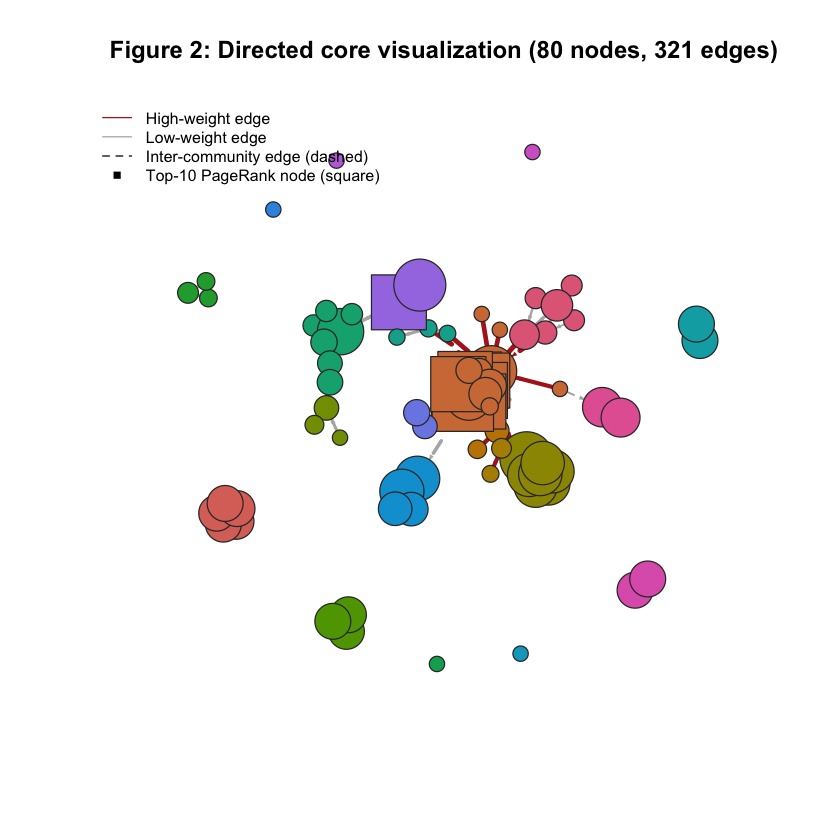

In [15]:
viz_bundle <- make_viz_subgraph(g_analysis, central_table, cfg)
g_viz <- viz_bundle$graph
viz_comm <- viz_bundle$community

stopifnot(vcount(g_viz) >= 30, vcount(g_viz) <= 100)

plot(
  g_viz,
  layout = layout_with_graphopt(g_viz),
  main = sprintf("Figure 2: Directed core visualization (%d nodes, %d edges)", vcount(g_viz), ecount(g_viz))
)
legend(
  "topleft",
  legend = c("High-weight edge", "Low-weight edge", "Inter-community edge (dashed)", "Top-10 PageRank node (square)"),
  col = c("firebrick", "gray70", "black", "black"),
  lty = c(1, 1, 2, NA),
  pch = c(NA, NA, NA, 15),
  bty = "n",
  cex = 0.8
)


**Figure 2 caption:** Directed simplified core with visual encodings for centrality, community membership, and weighted link intensity.

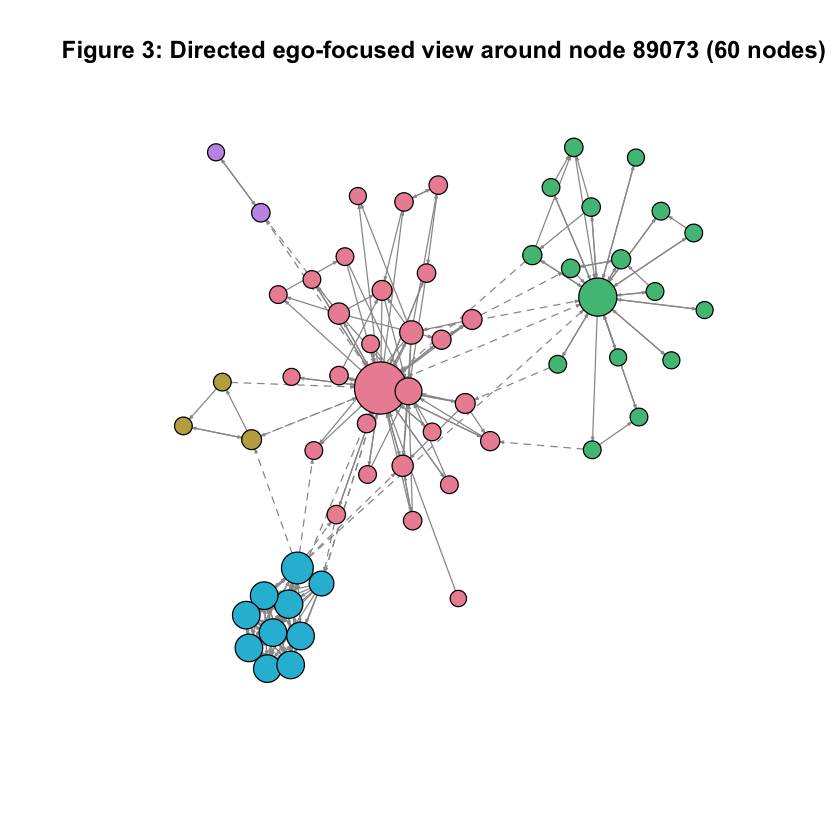

In [16]:
# Figure 3: Ego-focused view around the top central node
max_ego_plot_n <- 60
ego_plot <- ego_out_2

if (vcount(ego_plot) > max_ego_plot_n) {
  ego_pr <- page_rank(ego_plot, directed = TRUE)$vector
  keep <- names(sort(ego_pr, decreasing = TRUE))[1:max_ego_plot_n]
  ego_plot <- induced_subgraph(ego_plot, vids = V(ego_plot)[keep])
}

if (vcount(ego_plot) < 30) {
  # Fallback to top nodes from global viz to keep figure readable in assignment range
  fallback_nodes <- central_table$vertex[1:30]
  ego_plot <- induced_subgraph(g_analysis, vids = V(g_analysis)[fallback_nodes])
}

ego_comm <- cluster_infomap(ego_plot, e.weights = E(ego_plot)$weight)
mem <- membership(ego_comm)
mem_by_name <- setNames(mem, V(ego_plot)$name)

V(ego_plot)$color <- hcl.colors(length(unique(mem)), "Set 2")[mem_by_name[V(ego_plot)$name]]
V(ego_plot)$size <- 6 + 14 * degree(ego_plot, mode = "all") / max(1, max(degree(ego_plot, mode = "all")))
V(ego_plot)$label <- NA
E(ego_plot)$color <- "gray60"
E(ego_plot)$arrow.size <- 0.16

ee <- ends(ego_plot, E(ego_plot), names = TRUE)
E(ego_plot)$lty <- ifelse(mem_by_name[ee[,1]] == mem_by_name[ee[,2]], 1, 2)

plot(
  ego_plot,
  layout = layout_with_graphopt(ego_plot),
  main = sprintf("Figure 3: Directed ego-focused view around node %s (%d nodes)", focus_node, vcount(ego_plot))
)


**Figure 3 caption:** Directed ego-focused subgraph showing local structure and community segmentation around the top central node.

## 7. Listing of R / `igraph` Functions Used

In [17]:
functions_used <- c(
  # setup / data
  "install.packages", "requireNamespace", "library", "fread",
  # construction / simplification
  "graph_from_data_frame", "simplify", "components", "induced_subgraph",
  # structural summaries
  "vcount", "ecount", "edge_density", "degree", "any_loop", "is_directed",
  # item #4
  "is_connected", "page_rank", "eigen_centrality", "strength", "vertex_connectivity", "edge_connectivity",
  "dyad_census", "triad_census", "similarity", "eccentricity", "cluster_infomap", "subcomponent",
  # item #5
  "safe_power_centrality", "power_centrality", "diameter", "get_diameter", "largest_cliques", "make_ego_graph",
  # visualization
  "layout_with_graphopt", "plot", "legend",
  # accessors
  "V", "E", "ends", "as_undirected"
)

cat("Total unique functions listed:", length(unique(functions_used)), "
")
print(sort(unique(functions_used)))


Total unique functions listed: 39 


 [1] "any_loop"              "as_undirected"         "cluster_infomap"       "components"           
 [5] "degree"                "diameter"              "dyad_census"           "E"                    
 [9] "eccentricity"          "ecount"                "edge_connectivity"     "edge_density"         
[13] "eigen_centrality"      "ends"                  "fread"                 "get_diameter"         
[17] "graph_from_data_frame" "induced_subgraph"      "install.packages"      "is_connected"         
[21] "is_directed"           "largest_cliques"       "layout_with_graphopt"  "legend"               
[25] "library"               "make_ego_graph"        "page_rank"             "plot"                 
[29] "power_centrality"      "requireNamespace"      "safe_power_centrality" "similarity"           
[33] "simplify"              "strength"              "subcomponent"          "triad_census"         
[37] "V"                     "vcount"                "vertex_connectivity"  


## 8. What We Learned
1. **Incremental scaling matters:** We now evaluate checkpoints from 600 to 5,000 nodes before deep analysis on 1,800 nodes.
2. **Directionality remains essential:** Directed connectivity and path metrics reveal asymmetric reachability that undirected treatment would hide.
3. **The 1,800-node core is still fragmented:** weak/strong connectivity and connectivity-zero metrics show that this is a selective core, not a fully coherent whole.
4. **Weighted conclusions are sensitivity-checked:** synthetic weights are treated as an exploratory model, and we compare weighted vs unweighted outcomes directly.
5. **Graph-specific insights are stronger now:** motif dominance, reachability depth, overlap structure, and community counts are reported with concrete values.

### Problems encountered and solutions
- **Challenge:** aggressive reduction can weaken trust in representativeness.
  - **Solution:** add incremental multi-scale checkpoints and centrality overlap checks.
- **Challenge:** raw graph has no native weights.
  - **Solution:** keep unweighted analysis as baseline, then report weighted sensitivity side-by-side.
- **Challenge:** generic explanations do not satisfy analytical depth.
  - **Solution:** tie function interpretations to graph-specific numeric outcomes.


## Reproducibility Notes (Kaggle Guest Run)
- Dataset path is auto-resolved between local and Kaggle locations.
- Required packages are installed only if missing.
- Random operations are seeded (`cfg$seed`) for repeatability.
- Notebook is designed to run top-to-bottom without manual edits.


In [18]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: aarch64-apple-darwin20
Running under: macOS Sequoia 15.3.2

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] C.UTF-8/C/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: Asia/Baku
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] data.table_1.18.2.1 igraph_2.2.2       

loaded via a namespace (and not attached):
 [1] digest_0.6.39   IRdisplay_1.1   base64enc_0.1-6 fastmap_1.2.0   Matrix_1.7-4    lattice_0.22-7  magrittr_2.0.4 
 [8] glue_1.8.0      pkgconfig_2.0.3 htmltools_0.5.9 repr_1.1.7      lifecycle_1.0.5 cli_3.6.5       grid_4.5.2     
[15] vctrs_0.7.1     pbdZMQ_0.3-14   compiler_4.5.2  tools_4.5.2     evaluate_1.0.5  pillar_1.11.1 